### Find file paths

In [29]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        if f == 'vision_common_v5.py':
            print(os.path.join(root, f))

/kaggle/input/datasets/maryclauds/vision-common-v5/vision_common_v5.py


### Import the vision-common

In [35]:
import os
import sys

# Confirm vision-common actually mounted, and under what exact folder name -
# Kaggle sometimes normalizes the slug slightly differently than you typed.
print(os.listdir('/kaggle/input'))
sys.path.append('/kaggle/input/datasets/maryclauds/vision-common-v5')

from vision_common_v5 import (
    rectify_workspace,
    detect_marker,
    extract_shape_features,
    find_valid_contours,
    compute_contour_features,
)


['datasets']


### Train dir

In [36]:
train_dir = '/kaggle/input/datasets/maryclauds/vision-final-dataset/vision_final_dataset'

In [37]:
"""
Run this in Kaggle against your dataset folder. It shows every unique
"raw label" the filename regex is actually extracting, and how many files
fall under each - so we can see exactly why star/hexagon aren't matching
LABEL_MAP without guessing.
"""

import os
import re
from collections import Counter

train_dir = '/kaggle/input/datasets/maryclauds/vision-final-dataset/vision_final_dataset'

FILENAME_PATTERN = re.compile(
    r'^capture_(?P<label>.+)_(?P<idx>\d+)\.(jpg|jpeg|png)$',
    re.IGNORECASE
)

raw_labels = Counter()
unmatched = []

for filename in os.listdir(train_dir):
    m = FILENAME_PATTERN.match(filename)
    if not m:
        unmatched.append(filename)
        continue
    raw_labels[m.group('label').lower()] += 1

print("=== Raw label -> file count ===")
for label, count in raw_labels.most_common():
    print(f"  '{label}': {count} files")

if unmatched:
    print(f"\n=== {len(unmatched)} files didn't match the pattern at all (showing up to 10) ===")
    for f in unmatched[:10]:
        print("  ", f)

=== Raw label -> file count ===
  'star': 200 files
  'square': 200 files
  'hex': 200 files
  '2': 51 files
  '8': 51 files
  '6': 51 files
  '3': 51 files
  '10': 51 files
  '9': 51 files
  '4': 51 files
  '7': 51 files
  '11': 51 files
  '5': 51 files
  '1': 51 files
  'aruco_3_shapes': 30 files
  'aruco': 30 files
  '12': 29 files


In [38]:
"""
Loader for the full dataset. Two filename families now feed in:

  1) Original clean single-shape captures:
       capture_star_N.jpg / capture_square_N.jpg / capture_hex_N.jpg
     (one shape type per photo, well-lit, independently captured)

  2) New batch, different lighting exposure, added for robustness.
     Raw numeric label -> what's actually in frame (from Claudia, 2026-09-10):
       1  = aruco + square                -> single type (Square)  -> USE
       2  = aruco + square + star         -> multi type             -> EXCLUDE
       3  = aruco + square + star + hex   -> multi type             -> EXCLUDE
       4  = aruco + square + star + hex   -> multi type             -> EXCLUDE
       5  = aruco + square + star + hex + square -> multi type      -> EXCLUDE
       6  = aruco + square + star + hex + square -> multi type      -> EXCLUDE
       7  = square + square               -> single type (Square)  -> USE
       8  = hex                           -> single type (Hexagon) -> USE
       9  = star                          -> single type (Star)    -> USE
       10 = star                          -> single type (Star)    -> USE
       11 = aruco only                    -> marker-only            -> EXCLUDE
       12 = aruco only                    -> marker-only            -> EXCLUDE

     Labels 2-6 are excluded from classifier training: with more than one
     shape TYPE in frame, a single filename label can't be assigned to the
     right contour without knowing which contour is which - same reasoning
     that already excluded `aruco_3_shapes`. These frames are still useful
     later for testing the *live* multi-shape detection pipeline
     (find_valid_contours + per-contour classify in main_vision.py) - just
     not as labeled training rows here.

     Labels 11/12 are excluded for the same reason `aruco` always was:
     marker only, no shape to learn from.

IMPORTANT CHANGE: this now uses find_valid_contours() (ALL valid contours
in the frame) instead of extract_shape_features()'s largest-contour-only
behaviour. For single-shape-type frames this is free extra training data
whenever more than one instance of that shape is in frame (e.g. raw label
7, "square + square", now yields 2 training rows instead of 1). For the
old-style one-shape-per-photo captures it behaves identically to before
(exactly one valid contour), so this is a strict improvement, not a
behaviour change for the existing 593 samples.
"""

import re
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib
import pandas as pd
from collections import Counter

FILENAME_PATTERN = re.compile(
    r"^capture_(?P<label>.+)_(?P<idx>\d+)\.(jpg|jpeg|png)$",
    re.IGNORECASE
)

LABEL_MAP = {
    "star": "Star",
    "square": "Square",
    "hex": "Hexagon",
    "1": "Square",    # aruco + square
    "7": "Square",    # square + square
    "8": "Hexagon",   # hex only
    "9": "Star",      # star only
    "10": "Star",     # star only
}

# Raw labels we've confirmed are multi-shape-type or marker-only, so we can
# tell "known, deliberately excluded" apart from "unrecognized, check this"
# in the skip printout below.
KNOWN_EXCLUDED_RAW_LABELS = {"2", "3", "4", "5", "6", "11", "12", "aruco", "aruco_3_shapes"}


def load_labeled_dataset(folder_path):
    X, y = [], []
    skipped_known_excluded = Counter()
    skipped_unrecognized = Counter()
    skipped_no_contour = 0
    skipped_no_paper = 0
    skipped_no_marker = 0
    used_raw_label_counts = Counter()
    used_raw_label_sample_counts = Counter()

    for filename in os.listdir(folder_path):
        m = FILENAME_PATTERN.match(filename)
        if not m:
            continue

        raw_label = m.group("label").lower()
        label = LABEL_MAP.get(raw_label)

        if label is None:
            if raw_label in KNOWN_EXCLUDED_RAW_LABELS:
                skipped_known_excluded[raw_label] += 1
            else:
                skipped_unrecognized[raw_label] += 1
            continue

        image_path = os.path.join(folder_path, filename)
        img = cv2.imread(image_path)
        if img is None:
            continue

        # 1) Rectify FIRST — crop the frame down to just the paper.
        rectified = rectify_workspace(img)
        if rectified is None:
            # Paper's corners weren't found. Two choices:
            #  (a) skip the sample entirely (cleanest), or
            #  (b) fall back to the raw frame (what preprocess_frame does).
            # For TRAINING, skipping is safer — you don't want a sample whose
            # feature vector is contaminated by the table.
            skipped_no_paper += 1
            continue
        img = rectified

        # 2) Now detect marker/shape in the rectified image. Coordinates,
        #    mm_per_px and angle are all in rectified space, which is what
        #    compute_contour_features expects.
        marker = detect_marker(img)
        if marker is None:
            skipped_no_marker += 1
            continue

        valid_contours = find_valid_contours(img, exclude_bbox=marker["bbox"])
        if not valid_contours:
            skipped_no_contour += 1
            continue

        used_raw_label_counts[raw_label] += 1
        for c in valid_contours:
            features = compute_contour_features(c)
            if features is None:
                continue
            X.append(features)
            y.append(label)
            used_raw_label_sample_counts[raw_label] += 1

    print(f"Loaded {len(X)} labeled samples.")
    print(f"Skipped {skipped_no_paper} files where the paper wasn't found.")
    print(f"Skipped {skipped_no_marker} files where no ArUco marker was detected.")
    print(f"Skipped {skipped_no_contour} files with no valid shape contour.")

    print(f"Loaded {len(X)} labeled samples.")
    print(f"Skipped {skipped_no_contour} labeled files with no valid contour found - spot-check these.")

    print("\n=== Raw labels used, by files -> training rows ===")
    for raw_label, file_count in sorted(used_raw_label_counts.items()):
        print(f"  '{raw_label}' -> {LABEL_MAP[raw_label]}: {file_count} files, "
              f"{used_raw_label_sample_counts[raw_label]} rows "
              f"({used_raw_label_sample_counts[raw_label] - file_count} extra from multi-instance frames)")

    if skipped_known_excluded:
        print("\n=== Skipped - known excluded (multi-shape-type or marker-only) ===")
        for raw_label, count in sorted(skipped_known_excluded.items()):
            print(f"  '{raw_label}': {count} files")

    if skipped_unrecognized:
        print("\n=== Skipped - UNRECOGNIZED raw label, check LABEL_MAP/KNOWN_EXCLUDED_RAW_LABELS ===")
        for raw_label, count in sorted(skipped_unrecognized.items()):
            print(f"  '{raw_label}': {count} files")

    print("\n=== Final class balance ===")
    for shape in sorted(set(y)):
        print(f"  {shape}: {y.count(shape)} samples")

    return np.array(X), np.array(y)


## Load the data


In [39]:
X, y = load_labeled_dataset(train_dir)


Loaded 1160 labeled samples.
Skipped 0 files where the paper wasn't found.
Skipped 311 files where no ArUco marker was detected.
Skipped 0 files with no valid shape contour.
Loaded 1160 labeled samples.
Skipped 0 labeled files with no valid contour found - spot-check these.

=== Raw labels used, by files -> training rows ===
  '1' -> Square: 23 files, 92 rows (69 extra from multi-instance frames)
  '10' -> Star: 4 files, 26 rows (22 extra from multi-instance frames)
  '7' -> Square: 2 files, 8 rows (6 extra from multi-instance frames)
  '8' -> Hexagon: 1 files, 2 rows (1 extra from multi-instance frames)
  '9' -> Star: 8 files, 32 rows (24 extra from multi-instance frames)
  'hex' -> Hexagon: 175 files, 350 rows (175 extra from multi-instance frames)
  'square' -> Square: 156 files, 311 rows (155 extra from multi-instance frames)
  'star' -> Star: 175 files, 339 rows (164 extra from multi-instance frames)

=== Skipped - known excluded (multi-shape-type or marker-only) ===
  '11': 51 fi

## Stratified 80/20 split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")


Train: 928  Test: 232


#### confirm the crop fix works

v6_workspace_polygon_mask


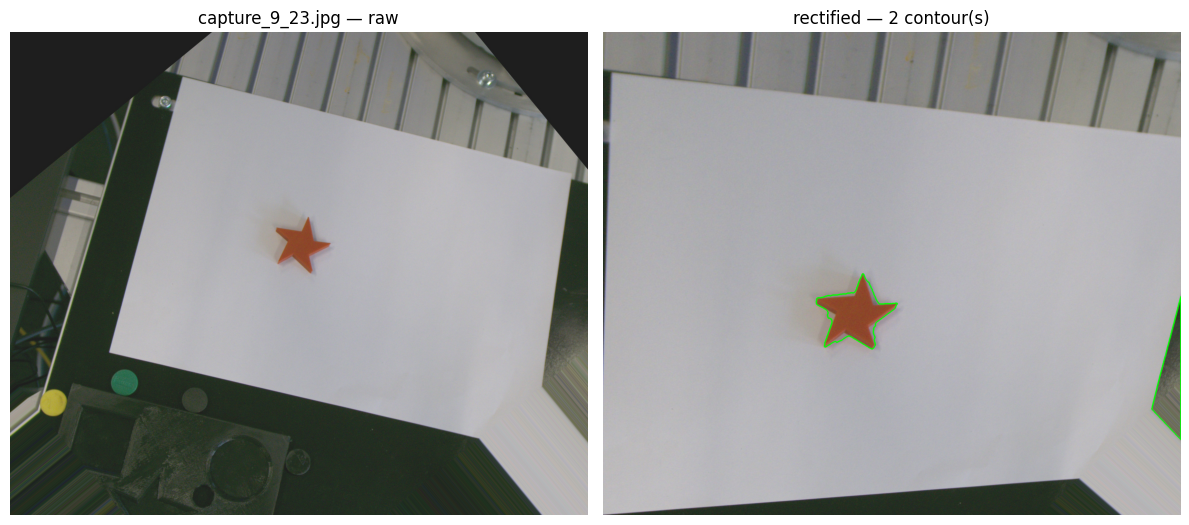

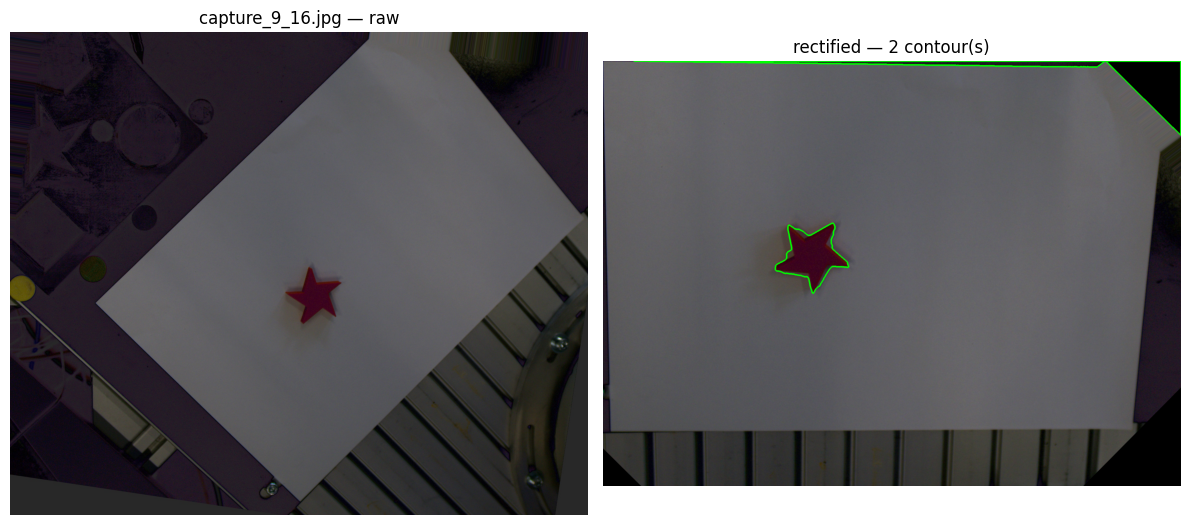

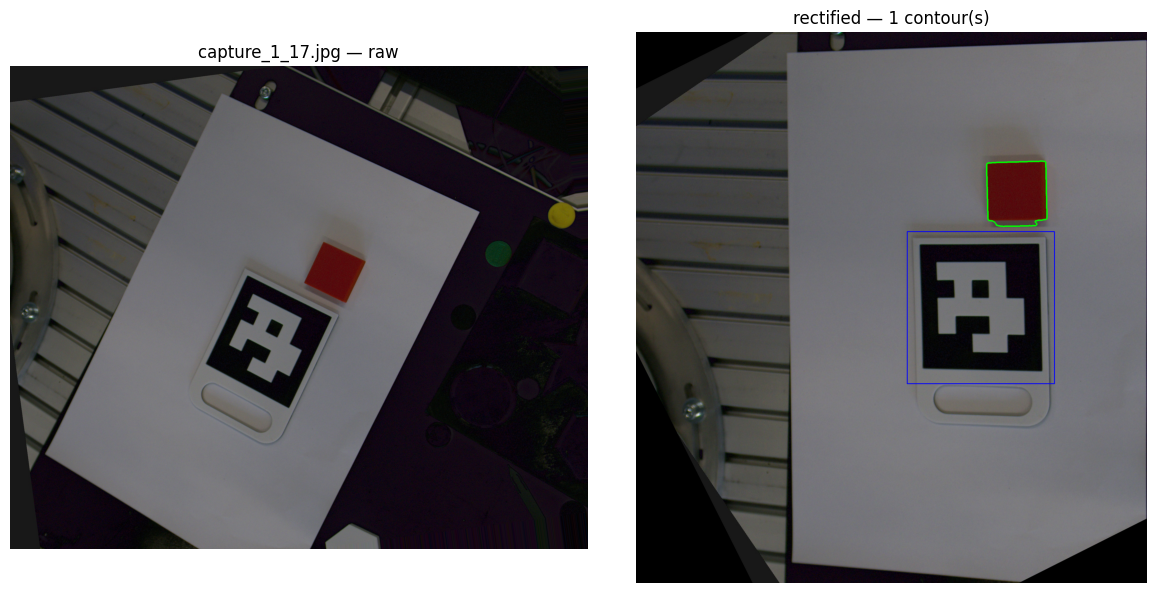

In [41]:
import vision_common_v5
import matplotlib.pyplot as plt  
print(vision_common_v3.VISION_COMMON_VERSION)  # should print v5_workspace_crop

sample_files = ['capture_9_23.jpg', 'capture_9_16.jpg', 'capture_1_17.jpg']

for fname in sample_files:
    raw = cv2.imread(os.path.join(train_dir, fname))
    rect = rectify_workspace(raw)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(cv2.cvtColor(raw, cv2.COLOR_BGR2RGB))
    axes[0].set_title(f"{fname} — raw")

    if rect is None:
        axes[1].text(0.5, 0.5, "paper NOT found\n(sample would be skipped)",
                     ha='center', va='center', fontsize=14)
        axes[1].axis('off')
    else:
        marker = detect_marker(rect)
        contours = find_valid_contours(
            rect, exclude_bbox=marker["bbox"] if marker else None
        )
        vis = rect.copy()
        if marker:
            x, y, w, h = marker["bbox"]
            cv2.rectangle(vis, (x, y), (x + w, y + h), (255, 0, 0), 2)
        cv2.drawContours(vis, contours, -1, (0, 255, 0), 3)
        axes[1].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        axes[1].set_title(f"rectified — {len(contours)} contour(s)")

    for ax in axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

## Train


In [42]:
clf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

     Hexagon       0.96      0.97      0.96        70
      Square       0.83      0.84      0.84        82
        Star       0.86      0.84      0.85        80

    accuracy                           0.88       232
   macro avg       0.88      0.88      0.88       232
weighted avg       0.88      0.88      0.88       232



## Confusion matrix

In [43]:
labels = sorted(np.unique(y_test))
cm = confusion_matrix(y_test, y_pred, labels=labels)
print(pd.DataFrame(cm, index=[f"actual_{l}" for l in labels], columns=[f"pred_{l}" for l in labels]))


                pred_Hexagon  pred_Square  pred_Star
actual_Hexagon            68            2          0
actual_Square              2           69         11
actual_Star                1           12         67


### See output

## Save the model for `main_vision.py`

In [ ]:
joblib.dump(clf, "shape_classifier.pkl")
print("Saved shape_classifier.pkl")
